### Data Loading

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 50)

# Turn off scientific notation in Pandas
pd.set_option('display.float_format', lambda x: '%.5f' % x)

import warnings
warnings.filterwarnings('ignore')

In [2]:
result = pd.read_csv('result_final_for_conclusion.csv')
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             966 non-null    int64  
 1   scheme_id              966 non-null    int64  
 2   start_date             966 non-null    int64  
 3   end_date               966 non-null    int64  
 4   ord_gmv                966 non-null    object 
 5   gmv                    966 non-null    int64  
 6   brand_id               966 non-null    int64  
 7   brand_name             966 non-null    object 
 8   industry               966 non-null    object 
 9   expose_period_wide     966 non-null    int64  
 10  expose_period_narrow   966 non-null    int64  
 11  expose_period_narrow2  966 non-null    int64  
 12  device_num             966 non-null    int64  
 13  poi_num                966 non-null    object 
 14  entity_num             966 non-null    object 
 15  device

In [3]:
# data type fix
result.replace('-',0,inplace=True)
result['expose_ta'] = result['expose_ta'].astype(float)
result['brand_shop_uv'] = result['brand_shop_uv'].astype(float)
result['gmv_avg'] = result['gmv_avg'].astype(float)
result['gmv_25'] = result['gmv_25'].astype(float)
result['uv_1month'] = result['uv_1month'].astype(float)
result['aipl_cnt'] = result['aipl_cnt'].astype(float)
result['a_ipl_rate'] = result['a_ipl_rate'].astype(float)

In [4]:
result[['level2_device_num','device_num']].replace(0,1,inplace=True)
result['device_num'].describe()

count   966.00000
mean      1.06108
std       0.35468
min       0.00000
25%       1.00000
50%       1.00000
75%       1.00000
max       4.00000
Name: device_num, dtype: float64

### Feature Engineering
##### 1. TA (Potential Costumer): expose TA rate

In [5]:
industry_mapping = {
    '个护家清': 331189361,
    '医疗健康': 159882570,
    '大小家电': 307340518,
    '宠物': 150464743,
    '家装': 307340518,
    '家装家居': 307340518,
    '服饰': 400766437,
    '母婴亲子': 370572629,
    '母婴玩具': 370572629,
    '电子家电': 307340518,
    '美妆': 319791602,
    '运动户外': 342873493,
    '食品饮料': 570908127,
    '3C数码': 167670969
}

result['ind_ta'] = result['industry'].map(industry_mapping)

In [6]:
result['ta_reach'] = result['expose_ta']/result['ind_ta']
result['ta_ratio'] = result['expose_ta']/result['expose_uv']

##### 2. CPUV & Expose days per person

In [7]:
result['cpuv'] = result['gmv']/result['expose_uv']
result['uv_expose_days'] = result['date_diff']/result['expose_uv']

##### 3. Brand Level: brand ranks among industry

In [8]:
industry_mapping_aipl = {
    '个护家清': 4543869,
    '医疗健康': 4108044,
    '大小家电': 3315969,
    '宠物': 2670303,
    '家装': 3315969,
    '家装家居': 3315969,
    '服饰': 2987648,
    '母婴亲子': 3909755,
    '母婴玩具': 3909755,
    '电子家电': 3315969,
    '美妆': 3096480,
    '运动户外': 3327943,
    '食品饮料': 2933842,
    '3C数码': 3137560
}

result['ind_aipl'] = result['industry'].map(industry_mapping_aipl)

result['aipl_rate'] = result['aipl_cnt']/result['ind_aipl']
result['aipl_rate'].describe()

count   927.00000
mean     11.85976
std      10.00137
min       0.00000
25%       5.05927
50%      10.46132
75%      14.87816
max      67.03406
Name: aipl_rate, dtype: float64

In [9]:
def brand_industry_comp(x):
    try:
        if x <= 5:
            return 0
        elif x > 5 and x <= 10:
            return 1
        elif x > 10 and x <= 15:
            return 2
        else:
            return 3
    except:
        return 0
result['brand_industry_comp'] = result['aipl_rate'].apply(lambda x: brand_industry_comp(x))

##### 4. Target

In [10]:
result['shoprate'] = result['shop_uv'].astype(float)/result['expose_uv'].astype(float)
result['shop_contribute'] = result['shop_uv'].astype(float)/result['brand_shop_uv'].astype(float)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             966 non-null    int64  
 1   scheme_id              966 non-null    int64  
 2   start_date             966 non-null    int64  
 3   end_date               966 non-null    int64  
 4   ord_gmv                966 non-null    object 
 5   gmv                    966 non-null    int64  
 6   brand_id               966 non-null    int64  
 7   brand_name             966 non-null    object 
 8   industry               966 non-null    object 
 9   expose_period_wide     966 non-null    int64  
 10  expose_period_narrow   966 non-null    int64  
 11  expose_period_narrow2  966 non-null    int64  
 12  device_num             966 non-null    int64  
 13  poi_num                966 non-null    object 
 14  entity_num             966 non-null    object 
 15  device

##### 5. Expose Period: is sale time

In [11]:
result[result['ind_aipl'].isin([4543869, 3096480, 2933842, 3909755, 3315969, 2987648])]

result['start'] = pd.to_datetime(result['start_date'], format='%Y%m%d')
result['end'] = pd.to_datetime(result['end_date'], format='%Y%m%d')

result['date_list'] = result.apply(
    lambda row: pd.date_range(start=row['start'], end=row['end'], freq='D'),
    axis=1
)

df_exploded = result.explode('date_list').reset_index(drop=True)
df_exploded.rename(columns={'date_list': 'date'}, inplace=True)

df_exploded['dt'] = df_exploded['date'].astype('str').str[5:10]
df_exploded['ind_aipl'].replace({4543869:'个护家清',3096480:'美妆',2933842:'食品饮料',3909755:'母婴',3315969:'家居',2987648:'服饰'},inplace=True)

dframe = df_exploded.query(
    "(dt >= '05-15' and dt <= '06-15' and ind_aipl == '个护家清') or (dt >= '04-10' and dt <= '05-10' and ind_aipl == '美妆') or (dt >= '09-15' and dt <= '10-15' and ind_aipl == '美妆') or (dt >= '05-10' and dt <= '06-10' and ind_aipl == '食品饮料') or (dt >= '10-01' and dt <= '11-20' and ind_aipl == '母婴') or (dt >= '10-01' and dt <= '11-20' and ind_aipl == '服饰') or (dt >= '10-20' and dt <= '11-10' and ind_aipl == '家居') or (dt >= '12-10' and dt <= '12-31' and ind_aipl == '家居')"
)

result['is_sale'] = result['scheme_id'].isin(dframe['scheme_id']).astype('int')
result['is_sale'].value_counts()

is_sale
0    729
1    237
Name: count, dtype: int64

In [12]:
result.isna().sum()

Unnamed: 0                0
scheme_id                 0
start_date                0
end_date                  0
ord_gmv                   0
gmv                       0
brand_id                  0
brand_name                0
industry                  0
expose_period_wide        0
expose_period_narrow      0
expose_period_narrow2     0
device_num                0
poi_num                   0
entity_num                0
device_type_list          0
city_num                  0
avg_city_level            0
city_level_list           0
expose_ta                 0
expose_uv                39
shop_uv                  39
brand_shop_uv            39
gmv_avg                  39
gmv_25                   39
uv_1month                39
aipl_num                 39
aipl_cnt                 39
date_diff                 0
a_ipl_rate                0
level2_device_num         0
ind_ta                    0
ta_reach                  0
ta_ratio                 39
cpuv                     39
uv_expose_days      

### Model - RF

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
import shap

In [14]:
def grid_search(X, y):
    param_grid = {
        'n_estimators': [20,50,100,200],
        'max_depth': [5,10,None],
        'min_samples_split': [10,20,50],
        'min_samples_leaf': [10,20,50],
    }  
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='r2'
    )
    grid_search.fit(X, y)
    return grid_search.best_params_, round(grid_search.best_score_,4)

MSE: 0.000033
MAE: 0.003867
R²: 0.831225


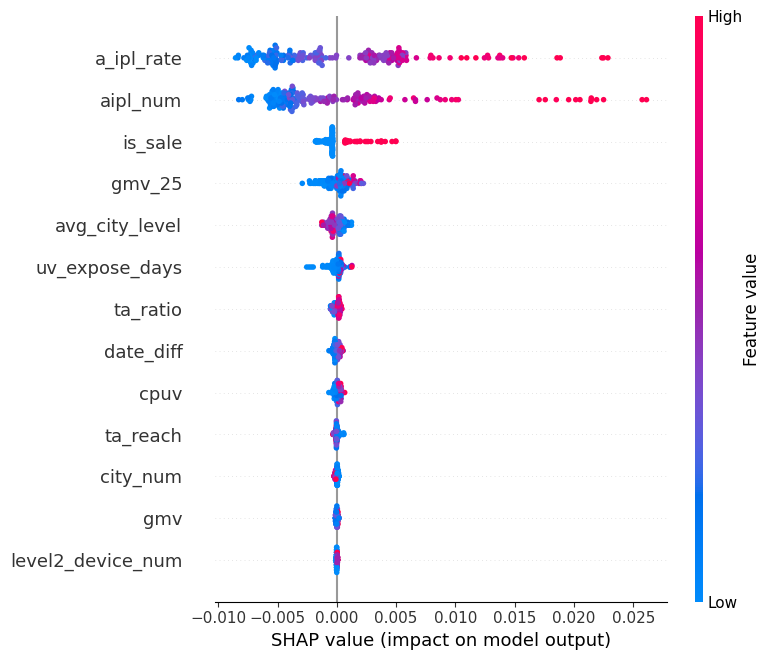

In [15]:
features = ['city_num','avg_city_level','date_diff','level2_device_num','ta_ratio','uv_expose_days','aipl_num',
            'gmv_25','a_ipl_rate','is_sale','gmv','cpuv','ta_reach']

result1 = result.dropna(subset=features+['shoprate'], how='any')

X = result1[features]
y = result1['shoprate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_prama, score = grid_search(X, y)
rf_model1 = RandomForestRegressor(
    n_estimators=best_prama['n_estimators'],
    max_depth=best_prama['max_depth'],
    min_samples_split=best_prama['min_samples_split'],
    min_samples_leaf=best_prama['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

rf_model1.fit(X_train, y_train)
explainer = shap.TreeExplainer(rf_model1)
y_pred = rf_model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model1.feature_importances_
}).sort_values(by='importance', ascending=False)

explainer = shap.Explainer(rf_model1, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values)

### Model - DML
##### 1. RF For X & Y

In [16]:
param_grid = {
    'n_estimators': [10,20,50,100,150,200],
    'max_depth': [5,10,20,None],
    'min_samples_split': [5,10,20,50],
    'min_samples_leaf': [5,10,20,50],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

# Conduct different models for each industry
X = result.query('ind_aipl == 2933842')[features]
y = result.query('ind_aipl == 2933842')['shoprate']
grid_search.fit(X, y)

print(f"Best Parameter: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

Best Parameter: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 10}
Best Score: 0.6816


##### 2. RF For X & D

In [17]:
features = ['city_num','avg_city_level','date_diff','level2_device_num','ta_ratio','uv_expose_days','aipl_num',
            'gmv_25','a_ipl_rate','is_sale','gmv','cpuv','ta_reach']

In [18]:
features

['city_num',
 'avg_city_level',
 'date_diff',
 'level2_device_num',
 'ta_ratio',
 'uv_expose_days',
 'aipl_num',
 'gmv_25',
 'a_ipl_rate',
 'is_sale',
 'gmv',
 'cpuv',
 'ta_reach']

In [19]:
param_grid = {
    'n_estimators': [10,20,50,100,150,200],
    'max_depth': [5,10,20,None],
    'min_samples_split': [5,10,20,50],
    'min_samples_leaf': [5,10,20,50],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

feature_copy = features.copy()
feature_copy.remove('aipl_num')

X1 = result.query('ind_aipl == 2933842')[feature_copy]
d = result.query('ind_aipl == 2933842')['aipl_num']
grid_search.fit(X1, d)

print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳分数: {grid_search.best_score_:.4f}")

最佳参数: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 10}
最佳分数: 0.5377


##### 3. Linear Model For X, D & Y

In [20]:
rf_model1 = RandomForestRegressor(
    n_estimators=10,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model1.fit(result1[features], result1['shoprate'])
y_pred1 = rf_model1.predict(result1[features])
result1['r1'] = result1['shoprate'] - y_pred1

rf_model2 = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model2.fit(result1[feature_copy], result1['aipl_num'])
y_pred2 = rf_model2.predict(result1[feature_copy])
result1['r2'] = result1['aipl_num'] - y_pred2

In [21]:
import statsmodels.api as sm

x_const = sm.add_constant(result1['r2'])
model = sm.OLS(result1['r1'], x_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     r1   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.462
Date:                Wed, 08 Jul 2026   Prob (F-statistic):              0.227
Time:                        17:37:41   Log-Likelihood:                 3598.2
No. Observations:                 927   AIC:                            -7192.
Df Residuals:                     925   BIC:                            -7183.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.529e-05      0.000     -0.215      0.8

##### 4. DML

In [22]:
def grid_search(X, y):
    param_grid = {
        'n_estimators': [20,50,100,200],
        'max_depth': [5,10,None],
        'min_samples_split': [10,20,50],
        'min_samples_leaf': [10,20,50],
    }  
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='r2'
    )
    grid_search.fit(X, y)
    return grid_search.best_params_, round(grid_search.best_score_,4)

def get_residual(Xtrain, ytrain, Xtest, ytest, params):
    rf_model = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(Xtrain, ytrain)
    y_pred = rf_model.predict(Xtest)
    residual = ytest - y_pred
    return residual

def get_ate(rt, ry):
    x_const = sm.add_constant(rt)
    model = sm.OLS(ry, x_const).fit()
    return model.params[1], model.pvalues[1]

In [25]:
import statsmodels.api as sm
industries = [4543869, 3096480, 2933842, 3909755, 3315969, 2987648]
indu_name = ['Personal Care & Household Cleaning','Beauty & Cosmetics','Food & Beverage','Maternal & Child','Home & Living','Apparel & Fashion']
features = ['a_ipl_rate','aipl_num','gmv_25','is_sale','avg_city_level','date_diff','ta_ratio','ta_reach','uv_expose_days','gmv']
target = 'shoprate'

industry_list = []
element = []
xyr2 = []
xtr2 = []
ate1_list = []
pvalue1_list = []
ate2_list = []
pvalue2_list = []

for idx, ind in enumerate(industries):
    dframe = result1.query('ind_aipl == @ind')
    dframe.dropna(inplace=True)
    xy_best_prama, xy_score = grid_search(dframe[features], dframe[target])
    
    for var in features:
        treatment_var = var
        features_new = [f for f in features if f != treatment_var]
        X1 = dframe[features_new]
        T = dframe[treatment_var]
        xt_best_param, xt_score = grid_search(X1, T)

        df1, df2 = train_test_split(dframe, test_size=0.5, random_state=42)
        #For df1=train, df2=test
        re_xy1 = get_residual(df1[features], df1[target], df2[features], df2[target], xy_best_prama)
        re_xt1 = get_residual(df1[features_new], df1[treatment_var], df2[features_new], df2[treatment_var], xt_best_param)
        ate1, pvalue1 = get_ate(re_xt1, re_xy1)
        #For df2=train, df1=test
        re_xy2 = get_residual(df2[features], df2[target], df1[features], df1[target], xy_best_prama)
        re_xt2 = get_residual(df2[features_new], df2[treatment_var], df1[features_new], df1[treatment_var], xt_best_param)
        ate2, pvalue2 = get_ate(re_xt2, re_xy2)

        industry_list.append(indu_name[idx])
        element.append(var)
        xyr2.append(xy_score)
        xtr2.append(xt_score)
        ate1_list.append(ate1)
        pvalue1_list.append(pvalue1)
        ate2_list.append(ate2)
        pvalue2_list.append(pvalue2)
        print(indu_name[idx], var)
        print(ate1, ate2)

causual_result = pd.DataFrame(columns=['Industry','Features','XY R2','XT R2','ATE1','P-value1','ATE2','P-value2'])
causual_result['Industry'] = industry_list
causual_result['Features'] = element
causual_result['XY R2'] = xyr2
causual_result['XT R2'] = xtr2
causual_result['ATE1'] = ate1_list
causual_result['P-value1'] = pvalue1_list
causual_result['ATE2'] = ate2_list
causual_result['P-value2'] = pvalue2_list

causual_result.round(10)

Personal Care & Household Cleaning a_ipl_rate
-0.026069766386982836 0.14707121360919023
Personal Care & Household Cleaning aipl_num
9.64171243077997e-11 1.1738190598285264e-10
Personal Care & Household Cleaning gmv_25
3.3037258101286616e-05 -8.197410291297871e-05
Personal Care & Household Cleaning is_sale
-0.0008861330304373004 0.00443851923828199
Personal Care & Household Cleaning avg_city_level
-0.003992040057156662 1.967668775723912e-05
Personal Care & Household Cleaning date_diff
3.90989235213959e-05 3.639020908846677e-05
Personal Care & Household Cleaning ta_ratio
-0.0032417743290715905 -0.0023577443169867443
Personal Care & Household Cleaning ta_reach
-0.017374677740159834 0.04865073593449078
Personal Care & Household Cleaning uv_expose_days
93.75608974842082 -72.37876201117014
Personal Care & Household Cleaning gmv
2.844596047719297e-12 2.964442719495237e-10
Beauty & Cosmetics a_ipl_rate
-0.1206910881359427 0.23232269926092602
Beauty & Cosmetics aipl_num
1.3034664324303836e-10 5

,Industry,Features,XY R2,XT R2,ATE1,P-value1,ATE2,P-value2
0,Personal Care & Household Cleaning,a_ipl_rate,0.58860,0.25420,-0.02607,0.46074,0.14707,0.00000
1,Personal Care & Household Cleaning,aipl_num,0.58860,0.32920,0.00000,0.05560,0.00000,0.00383
2,Personal Care & Household Cleaning,gmv_25,0.58860,0.07260,0.00003,0.52521,-0.00008,0.21278
3,Personal Care & Household Cleaning,is_sale,0.58860,-0.18190,-0.00089,0.73816,0.00444,0.05234
4,Personal Care & Household Cleaning,avg_city_level,0.58860,0.05410,-0.00399,0.02393,0.00002,0.99125
5,Personal Care & Household Cleaning,date_diff,0.58860,0.15230,0.00004,0.51025,0.00004,0.56589
6,Personal Care & Household Cleaning,ta_ratio,0.58860,-0.52840,-0.00324,0.22631,-0.00236,0.69130
7,Personal Care & Household Cleaning,ta_reach,0.58860,0.49620,-0.01737,0.56523,0.04865,0.24918
8,Personal Care & Household Cleaning,uv_expose_days,0.58860,0.27820,93.75609,0.77459,-72.37876,0.94774
9,Personal Care & Household Cleaning,gmv,0.58860,-0.13530,0.00000,0.98954,0.00000,0.45614
